In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score


In [ ]:
# ---------------------------------------------------------
# 1. DATA LOADING AND PREPROCESSING
# ---------------------------------------------------------
file_name = 'df_master_final.csv'

df = pd.read_csv(file_name)

df_finance = df[df['Category'] == 'Finance'].pivot(index='Year', columns='Name', values='Value').reset_index()
df_watches = df[df['Category'] != 'Finance'].copy()

df_final = pd.merge(df_watches, df_finance, on='Year', how='inner')
df_final = df_final.fillna(df_final.mean(numeric_only=True))
print("✅ Data successfully prepared for analysis.")
print(f"Dataset shape: {df_final.shape}")
df_final.head()


✅ Data successfully prepared for analysis.
Dataset shape: (688, 10)


In [ ]:
# ---------------------------------------------------------
# 2. K-MEANS CLUSTERING (Segmentation)
# ---------------------------------------------------------
features_cl = ['Value', 'Gold_USD', 'S&P500_Index', 'US_CPI_Index']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_final[features_cl])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_final['Cluster'] = kmeans.fit_predict(X_scaled)

print("✅ K-Means clustering complete.")
print(df_final['Cluster'].value_counts())


✅ K-Means clustering complete.
Cluster
1    312
0    256
2    120
Name: count, dtype: int64


In [ ]:
# ---------------------------------------------------------
# 3. RANDOM FOREST REGRESSION (Price Prediction)
# ---------------------------------------------------------
features_ml = ['Year', 'Gold_USD', 'Nasdaq_Index', 'S&P500_Index', 'US_CPI_Index', 'Cluster']
X = df_final[features_ml]
y = df_final['Value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(f"📊 Model Performance (R2 Score): {r2_score(y_test, y_pred):.4f}")


📊 Model Performance (R2 Score): 0.9429


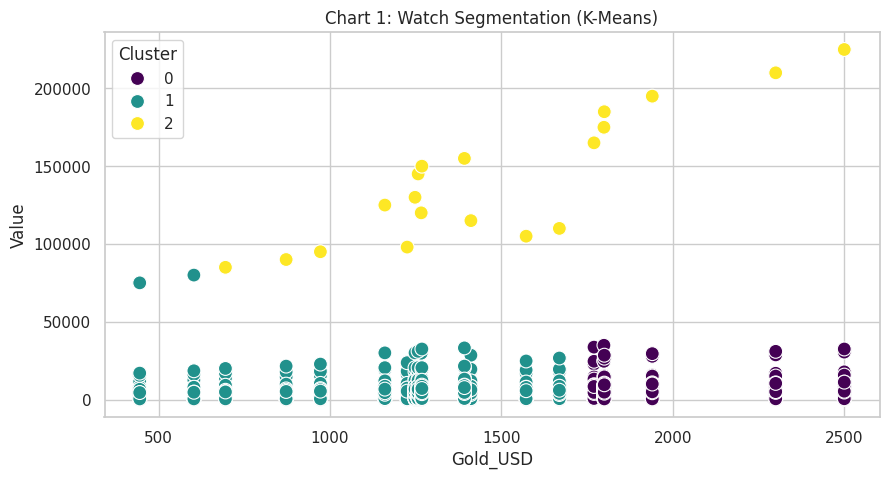

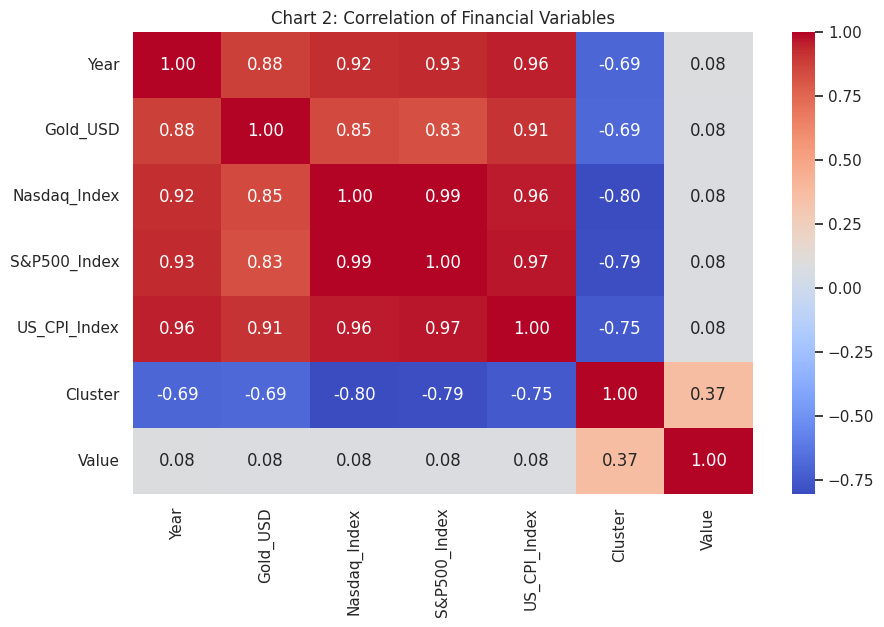

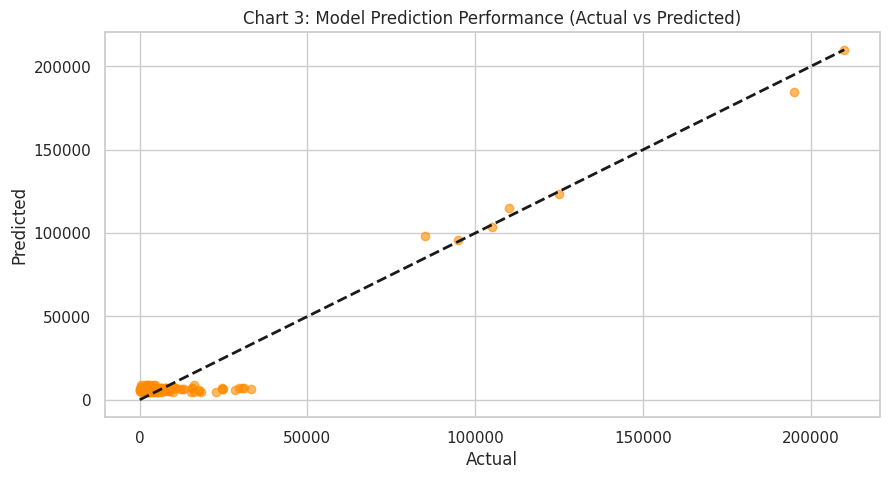

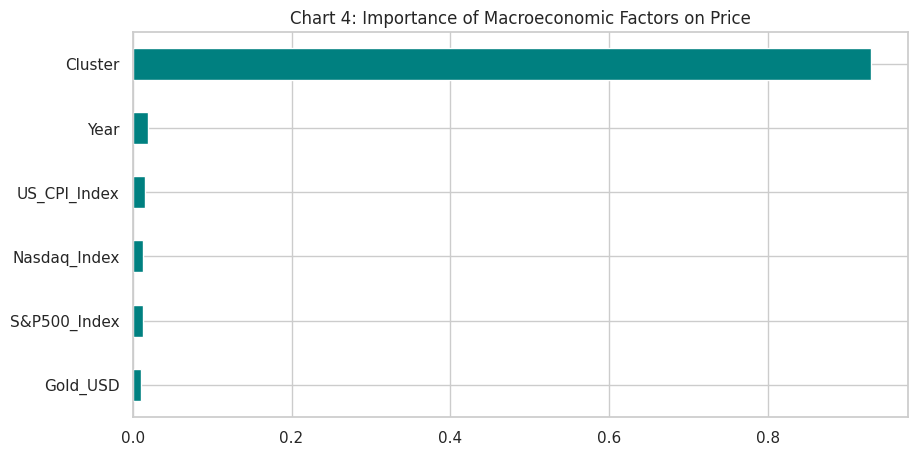

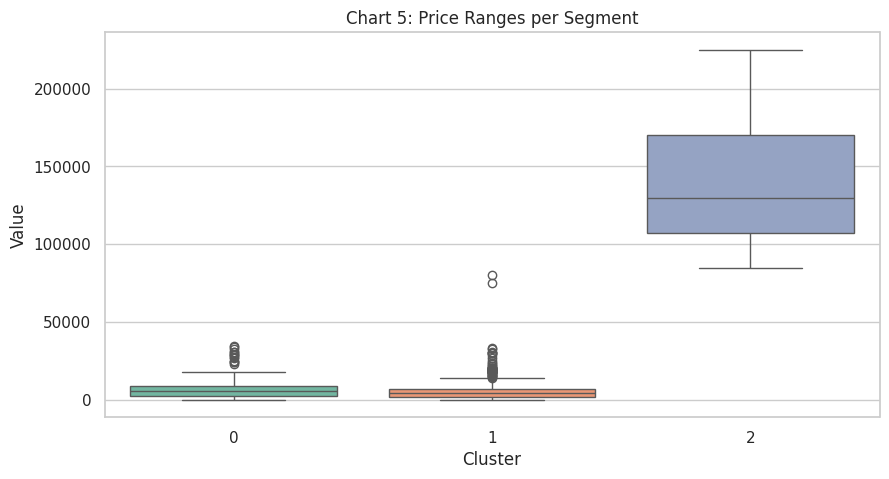

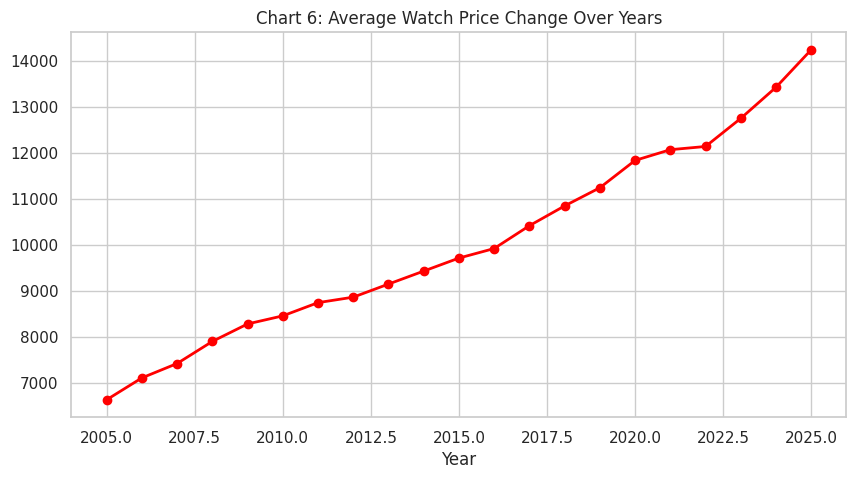

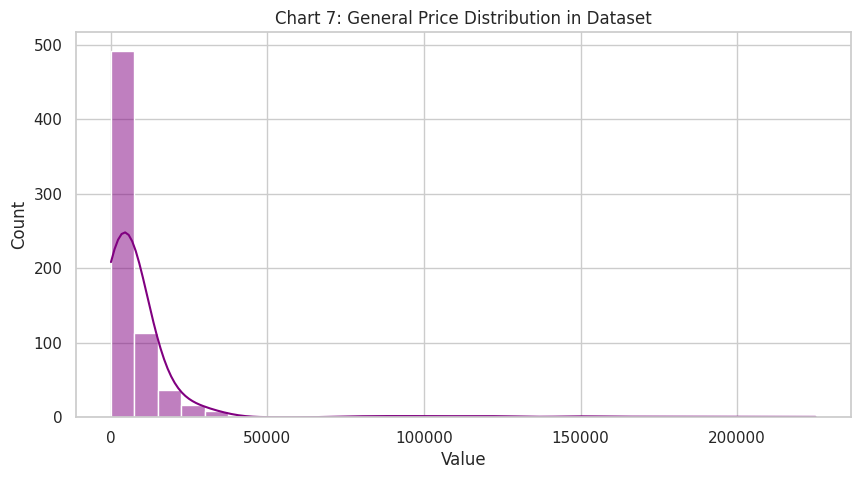

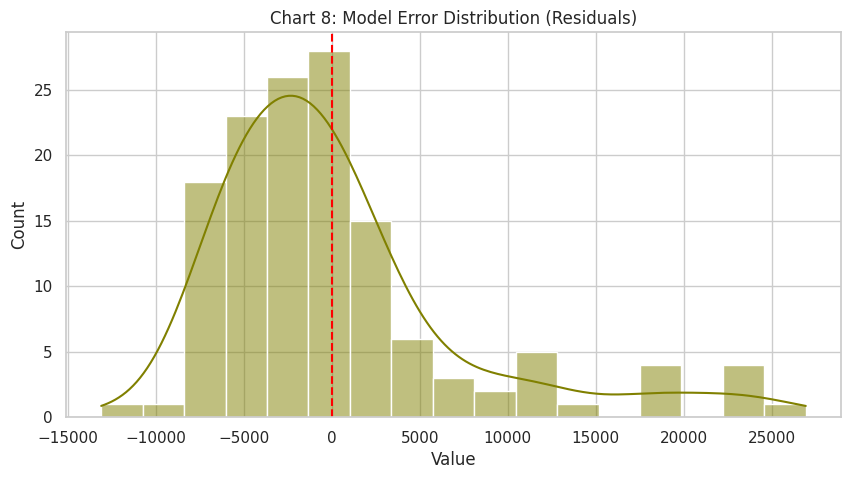

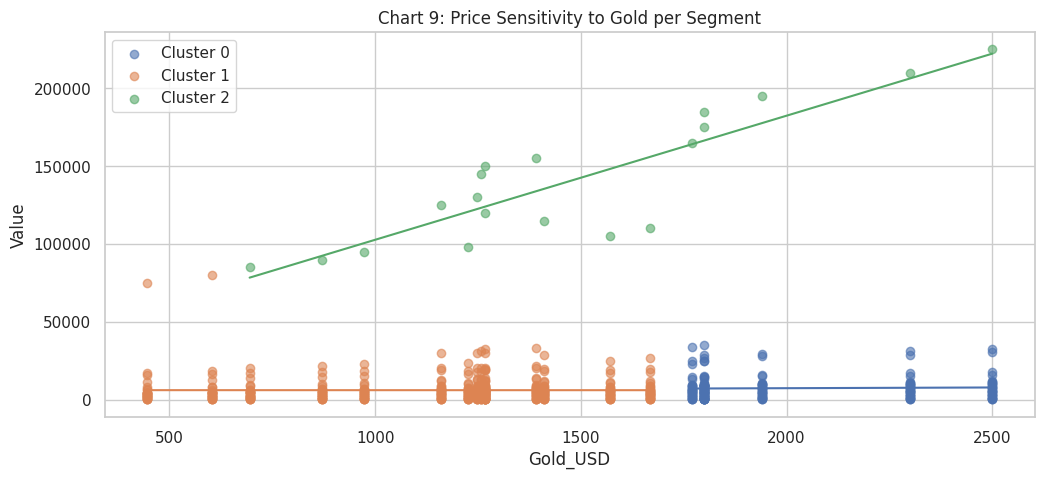

In [ ]:
# ---------------------------------------------------------
# 4. VISUALIZATION DASHBOARD (9 CHARTS)
# ---------------------------------------------------------
sns.set_theme(style="whitegrid")

# Chart 1: K-Means Distribution
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_final, x='Gold_USD', y='Value', hue='Cluster', palette='viridis', s=100)
plt.title('Chart 1: Watch Segmentation (K-Means)')
plt.show()

# Chart 2: Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_final[features_ml + ['Value']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Chart 2: Correlation of Financial Variables')
plt.show()

# Chart 3: Actual vs Predicted Prices
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, color='darkorange', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title('Chart 3: Model Prediction Performance (Actual vs Predicted)')
plt.xlabel('Actual'); plt.ylabel('Predicted')
plt.show()

# Chart 4: Feature Importance
importances = pd.Series(rf.feature_importances_, index=features_ml).sort_values(ascending=True)
plt.figure(figsize=(10, 5))
importances.plot(kind='barh', color='teal')
plt.title('Chart 4: Importance of Macroeconomic Factors on Price')
plt.show()

# Chart 5: Price Distribution by Cluster (Boxplot)
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_final, x='Cluster', y='Value', hue='Cluster', palette='Set2', legend=False)
plt.title('Chart 5: Price Ranges per Segment')
plt.show()

# Chart 6: Average Price Trend Over Time
plt.figure(figsize=(10, 5))
df_final.groupby('Year')['Value'].mean().plot(marker='o', color='red', lw=2)
plt.title('Chart 6: Average Watch Price Change Over Years')
plt.show()

# Chart 7: Price Distribution (Histogram)
plt.figure(figsize=(10, 5))
sns.histplot(df_final['Value'], bins=30, kde=True, color='purple')
plt.title('Chart 7: General Price Distribution in Dataset')
plt.show()

# Chart 8: Residual Analysis
plt.figure(figsize=(10, 5))
sns.histplot(y_test - y_pred, kde=True, color='olive')
plt.axvline(0, color='red', linestyle='--')
plt.title('Chart 8: Model Error Distribution (Residuals)')
plt.show()

# Chart 9: Gold Sensitivity Analysis
import numpy as np
plt.figure(figsize=(12, 5))
for c in sorted(df_final['Cluster'].unique()):
    sub = df_final[df_final['Cluster']==c]
    plt.scatter(sub['Gold_USD'], sub['Value'], label=f'Cluster {c}', alpha=0.6)
    m, b = np.polyfit(sub['Gold_USD'], sub['Value'], 1)
    xr = np.linspace(sub['Gold_USD'].min(), sub['Gold_USD'].max(), 100)
    plt.plot(xr, m*xr+b)
plt.title('Chart 9: Price Sensitivity to Gold per Segment')
plt.xlabel('Gold_USD'); plt.ylabel('Value'); plt.legend()
plt.show()


In [ ]:
# ---------------------------------------------------------
# 5. FUTURE SCENARIO PREDICTION
# ---------------------------------------------------------
future_scenario = pd.DataFrame({
    'Year': [2027], 'Gold_USD': [2850], 'Nasdaq_Index': [19500], 
    'S&P500_Index': [5800], 'US_CPI_Index': [120], 'Cluster': [2]
})
future_pred = rf.predict(future_scenario)

print("=" * 40)
print(f"🔮 2027 SCENARIO PREDICTION: {future_pred[0]:.2f} USD")
print("=" * 40)

# ---------------------------------------------------------
# 6. MODEL OUTLIER ANALYSIS
# ---------------------------------------------------------
df_final['Error'] = np.abs(df_final['Value'] - rf.predict(df_final[features_ml]))
outliers = df_final.sort_values(by='Error', ascending=False).head(3)
print("\n⚠️ WATCH MODELS WITH HIGHEST PREDICTION ERROR:")
print(outliers[['Name', 'Year', 'Value', 'Error']])


🔮 2027 SCENARIO PREDICTION: 183500.00 USD

⚠️ WATCH MODELS WITH HIGHEST PREDICTION ERROR:
                       Name  Year    Value         Error
46       Richard_Mille_RM011  2006  80000.0  71105.200747
17       Richard_Mille_RM011  2005  75000.0  67465.824297
536  Patek_Philippe_Nautilus  2021  34890.0  28440.765526
